## I. IMPORT THƯ VIỆN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib.ticker import FuncFormatter

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## II. LOAD VÀ KIỂM TRA DATASET

In [2]:
# Tải dataset lên notebook Kaggle
df_customer = pd.read_csv('/kaggle/input/marketingcampaign/marketing_campaign.csv', sep='\t')

# Hiển thị 5 dòng đầu tiên của dataset
df_customer.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
# Hiển thị các tên cột của dataset
col_names = df_customer.columns
col_names

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [4]:
# Hiển thị tóm tắt và kích thước của dataset
df_customer.info()
df_customer.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

(2240, 29)

Vậy, dựa trên các thông tin đã biết ở trên, có **29 cột (biến)** và  **2,240 dòng** cần được phân tích và làm sạch, dựa trên quan sát thì chúng được phân loại thành một số mục như sau:

1. **Con người**:
- ID: Mã số định danh duy nhất cho mỗi khách hàng.
- Year_Birth: Năm sinh của khách hàng.
- Education: Trình độ học vấn của khách hàng.
- Marital_Status: Tình trạng hôn nhân của khách hàng.
- Income: Thu nhập hàng năm của khách hàng.
- Kidhome: Số trẻ em trong gia đình.
- Teenhome: Số thanh thiếu niên trong gia đình.
- Dt_Customer: Ngày đăng ký khách hàng thân thiết (membership).
- Recency: Số ngày kể từ ngày mua hàng gần nhất.
- Complain: 1 nếu khách hàng đã từng khiếu nại trong 2 năm qua, 0 nếu ngược lại.

2. **Sản phẩm, số tiền chi tiêu cho các danh mục sản phẩm khác nhau trong 2 năm qua**:
- MntWines: Các sản phẩm rượu vang.
- MntFruits: Các sản phẩm trái cây.
- MntMeatProducts: Các sản phẩm thịt.
- MntFishProducts: Các sản phẩm cá.
- MntSweetProducts: Các sản phẩm kẹo và đồ ngọt.
- MntGoldProds: Các sản phẩm vàng và kim loại quý.

3. **Chiến dịch khuyến mại**:
- NumDealsPurchases: Số lần mua hàng được giảm giá.
- AcceptedCmp1:	1 nếu khách hàng tham gia hưởng ưu đãi trong chiến dịch thứ 1, 0 nếu ngược lại.
- AcceptedCmp2:	1 nếu khách hàng tham gia hưởng ưu đãi trong chiến dịch thứ 2, 0 nếu ngược lại.
- AcceptedCmp3:	1 nếu khách hàng tham gia hưởng ưu đãi trong chiến dịch thứ 3, 0 nếu ngược lại.
- AcceptedCmp4:	1 nếu khách hàng tham gia hưởng ưu đãi trong chiến dịch thứ 4, 0 nếu ngược lại.
- AcceptedCmp5:	1 nếu khách hàng tham gia hưởng ưu đãi trong chiến dịch thứ 5, 0 nếu ngược lại.
- Response:	1 nếu khách hàng tham gia hưởng ưu đãi trong chiến dịch thứ gần nhất, 0 nếu ngược lại.

4. **Nền tảng mua hàng**:
- NumWebPurchases: Số lần mua hàng qua trang web.
- NumCatalogPurchases: Số lần mua hàng sử dụng catalog.
- NumStorePurchases: Số lần mua hàng trực tiếp tại cửa hàng.
- NumWebVisitsMonth: Số lần khách ghé trang web trong 1 tháng vừa qua.

5. **Khác**:
- Z_CostContact: Hằng số, liên quan tới chi phí liên hệ khách hàng.
- Z_Revenue: Hằng số, liên quan tới doanh thu khách hàng.

Ước tính **khoảng thời gian thu thập dữ liệu** bằng cách kiểm tra biến **Dt_Customer**.

In [5]:
# Đặt timeframe là ngày-tháng-năm với Python
df_customer['Dt_Customer'] = pd.to_datetime(df_customer['Dt_Customer'], dayfirst=True)

# Kiểm tra phạm vi ngày tháng đăng ký của khách hàng
print("Earliest date of customer enrollment is", df_customer['Dt_Customer'].min())
print("Latest date of customer enrollment is", df_customer['Dt_Customer'].max())

Earliest date of customer enrollment is 2012-07-30 00:00:00
Latest date of customer enrollment is 2014-06-29 00:00:00


In [6]:
# Đếm số lượng khách hàng đăng ký theo từng năm từ 2012 đến 2014
df_customer['Dt_Customer'].dt.year.value_counts().sort_index()

Dt_Customer
2012     494
2013    1189
2014     557
Name: count, dtype: int64

Dựa vào thông tin trên, dữ liệu **có thể được thu thập từ 2012 đến 2014 (2 năm)**, bắt đầu từ 30/07/2012 tới khoảng 29/06/2014.

## III. CHUẨN BỊ DỮ LIỆU

### PHẦN 1

Trước khi phân tích dữ liệu,.. Thực hiện một số thủ tục như sau:

1. Kiểm tra các giá trị độc nhất (unique) của từng trường.
2. Kiểm tra tỉ lệ xuất hiện của chúng.
3. Xử lý các bản ghi trùng lặp.
4. Xử lý các giá trị bị thiếu.

**1. Kiểm tra các giá trị độc nhất trong từng trường**

Trường **ID** chắc chắn là trường có các giá trị độc nhất nên không cần kiểm tra các giá trị độc nhất của nó.

In [7]:
# Hiển thị tỉ lệ của từng giá trị trong trường "Year_Birth"
df_customer["Year_Birth"].value_counts(normalize=True).mul(100).round(2).sort_index()

Year_Birth
1893    0.04
1899    0.04
1900    0.04
1940    0.04
1941    0.04
1943    0.31
1944    0.31
1945    0.36
1946    0.71
1947    0.71
1948    0.94
1949    1.34
1950    1.29
1951    1.92
1952    2.32
1953    1.56
1954    2.23
1955    2.19
1956    2.46
1957    1.92
1958    2.37
1959    2.28
1960    2.19
1961    1.61
1962    1.96
1963    2.01
1964    1.88
1965    3.30
1966    2.23
1967    1.96
1968    2.28
1969    3.17
1970    3.44
1971    3.88
1972    3.53
1973    3.30
1974    3.08
1975    3.71
1976    3.97
1977    2.32
1978    3.44
1979    2.37
1980    1.74
1981    1.74
1982    2.01
1983    1.88
1984    1.70
1985    1.43
1986    1.88
1987    1.21
1988    1.29
1989    1.34
1990    0.80
1991    0.67
1992    0.58
1993    0.22
1994    0.13
1995    0.22
1996    0.09
Name: proportion, dtype: float64

In [8]:
# Hiển thị tỉ lệ của từng giá trị trong trường "Education"
df_customer["Education"].value_counts(normalize=True).mul(100).round(2).sort_index()

Education
2n Cycle       9.06
Basic          2.41
Graduation    50.31
Master        16.52
PhD           21.70
Name: proportion, dtype: float64

In [9]:
# Hiển thị tỉ lệ của từng giá trị trong trường "Marital_Status"
df_customer["Marital_Status"].value_counts(normalize=True).mul(100).round(2).sort_index()

# Kiểm tra các kết quả bên dưới, có một số giá trị bất thường của Marital_Status
# Chẳng hạn, Absurd, Alone và YOLO không có ý nghĩa gì cả

Marital_Status
Absurd       0.09
Alone        0.13
Divorced    10.36
Married     38.57
Single      21.43
Together    25.89
Widow        3.44
YOLO         0.09
Name: proportion, dtype: float64

In [10]:
# Hiển thị tỉ lệ của từng giá trị trong trường "Income"
df_customer["Income"].value_counts(normalize=True).mul(100).round(2).sort_index()

Income
1730.0      0.05
2447.0      0.05
3502.0      0.05
4023.0      0.05
4428.0      0.05
            ... 
157243.0    0.05
157733.0    0.05
160803.0    0.05
162397.0    0.05
666666.0    0.05
Name: proportion, Length: 1974, dtype: float64

In [11]:
# Hiển thị tỉ lệ của từng giá trị trong trường "Kidhome"
df_customer["Kidhome"].value_counts(normalize=True).mul(100).round(2).sort_index()

Kidhome
0    57.72
1    40.13
2     2.14
Name: proportion, dtype: float64

In [12]:
# Hiển thị tỉ lệ của từng giá trị trong trường "Teenhome"
df_customer["Teenhome"].value_counts(normalize=True).mul(100).round(2).sort_index()

Teenhome
0    51.70
1    45.98
2     2.32
Name: proportion, dtype: float64

In [13]:
# Hiển thị tỉ lệ của từng giá trị trong trường "Dt_Customer"
df_customer["Dt_Customer"].value_counts(normalize=True).mul(100).round(2).sort_index()

Dt_Customer
2012-07-30    0.04
2012-07-31    0.04
2012-08-01    0.18
2012-08-02    0.13
2012-08-03    0.22
              ... 
2014-06-25    0.22
2014-06-26    0.18
2014-06-27    0.13
2014-06-28    0.13
2014-06-29    0.09
Name: proportion, Length: 663, dtype: float64

In [14]:
# Hiển thị tỉ lệ của từng giá trị trong trường "Recency"
df_customer["Recency"].value_counts(normalize=True).mul(100).round(2).sort_index()

Recency
0     1.25
1     1.07
2     1.25
3     1.29
4     1.21
      ... 
95    0.85
96    1.12
97    0.89
98    0.98
99    0.76
Name: proportion, Length: 100, dtype: float64

In [15]:
# Hiển thị tỉ lệ của từng giá trị trong trường "Complain"
df_customer["Complain"].value_counts(normalize=True).mul(100).round(2).sort_index()

Complain
0    99.06
1     0.94
Name: proportion, dtype: float64

In [16]:
# Hiển thị tỉ lệ của từng giá trị trong trường "MntWines"
df_customer["MntWines"].value_counts(normalize=True).mul(100).round(2).sort_index()

MntWines
0       0.58
1       1.65
2       1.88
3       1.34
4       1.47
        ... 
1462    0.04
1478    0.09
1486    0.04
1492    0.09
1493    0.04
Name: proportion, Length: 776, dtype: float64

In [17]:
# Hiển thị tỉ lệ của từng giá trị trong trường "MntFruits"
df_customer["MntFruits"].value_counts(normalize=True).mul(100).round(2).sort_index()

MntFruits
0      17.86
1       7.23
2       5.36
3       5.18
4       4.64
       ...  
190     0.04
193     0.09
194     0.13
197     0.04
199     0.09
Name: proportion, Length: 158, dtype: float64

In [18]:
# Hiển thị tỉ lệ của từng giá trị trong trường "MntMeatProducts"
df_customer["MntMeatProducts"].value_counts(normalize=True).mul(100).round(2).sort_index()

MntMeatProducts
0       0.04
1       0.62
2       1.34
3       1.79
4       1.34
        ... 
984     0.04
1582    0.04
1607    0.04
1622    0.04
1725    0.09
Name: proportion, Length: 558, dtype: float64

In [19]:
# Hiển thị tỉ lệ của từng giá trị trong trường "MntFishProducts"
df_customer["MntFishProducts"].value_counts(normalize=True).mul(100).round(2).sort_index()

MntFishProducts
0      17.14
1       0.45
2       6.96
3       5.80
4       4.82
       ...  
250     0.13
253     0.04
254     0.04
258     0.13
259     0.04
Name: proportion, Length: 182, dtype: float64

In [20]:
# Hiển thị tỉ lệ của từng giá trị trong trường "MntSweetProducts"
df_customer["MntSweetProducts"].value_counts(normalize=True).mul(100).round(2).sort_index()

MntSweetProducts
0      18.71
1       7.19
2       5.71
3       4.51
4       3.66
       ...  
196     0.04
197     0.04
198     0.04
262     0.04
263     0.04
Name: proportion, Length: 177, dtype: float64

In [21]:
# Hiển thị tỉ lệ của từng giá trị trong trường "MntGoldProds"
df_customer["MntGoldProds"].value_counts(normalize=True).mul(100).round(2).sort_index()

MntGoldProds
0      2.72
1      3.26
2      2.77
3      3.08
4      3.12
       ... 
249    0.04
262    0.04
291    0.04
321    0.04
362    0.04
Name: proportion, Length: 213, dtype: float64

In [22]:
# Hiển thị tỉ lệ của từng giá trị trong trường "NumDealsPurchases"
df_customer["NumDealsPurchases"].value_counts(normalize=True).mul(100).round(2).sort_index()

NumDealsPurchases
0      2.05
1     43.30
2     22.19
3     13.26
4      8.44
5      4.20
6      2.72
7      1.79
8      0.62
9      0.36
10     0.22
11     0.22
12     0.18
13     0.13
15     0.31
Name: proportion, dtype: float64

In [23]:
# Hiển thị tỉ lệ của từng giá trị trong trường "AcceptedCmp1"
df_customer["AcceptedCmp1"].value_counts(normalize=True).mul(100).round(2).sort_index()

AcceptedCmp1
0    93.57
1     6.43
Name: proportion, dtype: float64

In [24]:
# Hiển thị tỉ lệ của từng giá trị trong trường "AcceptedCmp2"
df_customer["AcceptedCmp2"].value_counts(normalize=True).mul(100).round(2).sort_index()

AcceptedCmp2
0    98.66
1     1.34
Name: proportion, dtype: float64

In [25]:
# Hiển thị tỉ lệ của từng giá trị trong trường "AcceptedCmp3"
df_customer["AcceptedCmp3"].value_counts(normalize=True).mul(100).round(2).sort_index()

AcceptedCmp3
0    92.72
1     7.28
Name: proportion, dtype: float64

In [26]:
# Hiển thị tỉ lệ của từng giá trị trong trường "AcceptedCmp4"
df_customer["AcceptedCmp4"].value_counts(normalize=True).mul(100).round(2).sort_index()

AcceptedCmp4
0    92.54
1     7.46
Name: proportion, dtype: float64

In [27]:
# Hiển thị tỉ lệ của từng giá trị trong trường "AcceptedCmp5"
df_customer["AcceptedCmp5"].value_counts(normalize=True).mul(100).round(2).sort_index()

AcceptedCmp5
0    92.72
1     7.28
Name: proportion, dtype: float64

In [28]:
# Hiển thị tỉ lệ của từng giá trị trong trường "Response"
df_customer["Response"].value_counts(normalize=True).mul(100).round(2).sort_index()

Response
0    85.09
1    14.91
Name: proportion, dtype: float64

In [29]:
# Hiển thị tỉ lệ của từng giá trị trong trường "NumWebPurchases"
df_customer["NumWebPurchases"].value_counts(normalize=True).mul(100).round(2).sort_index()

NumWebPurchases
0      2.19
1     15.80
2     16.65
3     15.00
4     12.50
5      9.82
6      9.15
7      6.92
8      4.55
9      3.35
10     1.92
11     1.96
23     0.04
25     0.04
27     0.09
Name: proportion, dtype: float64

In [30]:
# Hiển thị tỉ lệ của từng giá trị trong trường "NumCatalogPurchases"
df_customer["NumCatalogPurchases"].value_counts(normalize=True).mul(100).round(2).sort_index()

NumCatalogPurchases
0     26.16
1     22.19
2     12.32
3      8.21
4      8.12
5      6.25
6      5.71
7      3.53
8      2.46
9      1.88
10     2.14
11     0.85
22     0.04
28     0.13
Name: proportion, dtype: float64

In [31]:
# Hiển thị tỉ lệ của từng giá trị trong trường "NumStorePurchases"
df_customer["NumStorePurchases"].value_counts(normalize=True).mul(100).round(2).sort_index()

NumStorePurchases
0      0.67
1      0.31
2      9.96
3     21.88
4     14.42
5      9.46
6      7.95
7      6.38
8      6.65
9      4.73
10     5.58
11     3.62
12     4.69
13     3.71
Name: proportion, dtype: float64

In [32]:
# Hiển thị tỉ lệ của từng giá trị trong trường "NumWebVisitsMonth"
df_customer["NumWebVisitsMonth"].value_counts(normalize=True).mul(100).round(2).sort_index()

NumWebVisitsMonth
0      0.49
1      6.83
2      9.02
3      9.15
4      9.73
5     12.54
6     15.18
7     17.54
8     15.27
9      3.71
10     0.13
13     0.04
14     0.09
17     0.04
19     0.09
20     0.13
Name: proportion, dtype: float64

**2. Kiểm tra phân phối dữ liệu**

Kiểm tra phân phối dữ liệu(min, max, và quantile) của các trường.

In [33]:
df_customer[["Year_Birth", "Income", "Kidhome", "Teenhome", 
             "Recency", "MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds",
            "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
            "NumStorePurchases", "NumWebVisitsMonth"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year_Birth,2240.0,1968.81,11.98,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.25,25173.08,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.44,0.54,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.51,0.54,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.94,336.60,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.30,39.77,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.95,225.72,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.53,54.63,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.06,41.28,0.0,1.00,8.0,33.00,263.0


**3. Xử lý các giá trị trùng lặp**

Kiểm tra các bản ghi trùng lặp. Cách tốt nhất là kiểm tra trường **ID** vì mỗi khách hàng chỉ có 1 ID duy nhất.



In [34]:
# Kiểm tra các bản ghi trùng lặp dựa trên trường ID
# keep=False để đánh dấu tất cả các bản ghi trùng lặp
duplicated_value = df_customer.duplicated(subset=["ID"], keep=False)
df_customer_duplicate = df_customer[duplicated_value].sort_values(by=["ID"])

# Hiển thị các bản ghi trùng lặp
df_customer_duplicate

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response


Kết quả trả về cho thấy không có bản ghi nào trùng lặp

**4. Xử lý các giá trị bị thiếu**

Tiếp theo, tiến hành kiểm tra các giá trị bị thiếu.

In [35]:
# Kiểm tra các cột thiếu dữ liệu và đếm số ô bị thiếu dữ liệu
df_customer.isnull().sum()[df_customer.isnull().sum() > 0]

Income    24
dtype: int64

In [36]:
# Hiển thị các bản ghi có giá trị bị thiếu
df_customer[df_customer.isnull().any(axis=1)]

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,2013-11-15,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,2013-11-05,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,2014-01-01,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,2013-06-17,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,2012-11-19,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,2014-05-27,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,2013-11-23,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,2013-07-11,23,352,...,6,0,0,0,0,0,0,3,11,0


Có 24 bản ghi bị thiếu dữ liệu "Income" trong dataset. Các giá trị bị thiếu sẽ được thay thế bằng giá trị median của "Income"

In [37]:
median_income = df_customer["Income"].median()
df_customer["Income"] = df_customer["Income"].fillna(median_income)

In [38]:
# Kiểm tra lại xem còn giá trị bị thiếu không
df_customer.isnull().sum()[df_customer.isnull().sum() > 0]

Series([], dtype: int64)

In [39]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

Vậy là đã không còn giá trị nào bị thiếu trong dataset, tiếp tục xử lý các điểm bất thường trong dataset

### PHẦN 2

Trong phần này sẽ xử lý các giá trị bất thường, ngoại lai,...

Trước đó ta đã thấy một số giá trị kỳ lạ trong trường **Marital-Status**, hãy xem lại các bản ghi chứa chúng.

In [40]:
# Hiển thị các dòng chứa giá trị bất thường trong trường Marital_Status
unclear_marital_status = ['Absurd', 'Alone', 'YOLO']
df_unclear_marital_status = df_customer[df_customer['Marital_Status'].isin(unclear_marital_status)]
print(df_unclear_marital_status)

         ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
131     433        1958      Master          Alone  61331.0        1   
138    7660        1973         PhD          Alone  35860.0        1   
153      92        1988  Graduation          Alone  34176.0        1   
2093   7734        1993  Graduation         Absurd  79244.0        0   
2134   4369        1957      Master         Absurd  65487.0        0   
2177    492        1973         PhD           YOLO  48432.0        0   
2202  11133        1973         PhD           YOLO  48432.0        0   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
131          1  2013-03-10       42       534  ...                  8   
138          1  2014-05-19       37        15  ...                  5   
153          0  2014-05-12       12         5  ...                  6   
2093         0  2012-12-19       58       471  ...                  1   
2134         0  2014-01-10       48       240  ...        

In [41]:
# Đếm số lượng các giá trị bất thường trong trường Marital_Status
print(df_unclear_marital_status['Marital_Status'].value_counts())

Marital_Status
Alone     3
Absurd    2
YOLO      2
Name: count, dtype: int64


Các giá trị khác trong 7 hàng chứa giá trị tại trường **Marital_Status** bất thường trông có vẻ bình thường, nên tôi chuyển các giá trị bất thường này thành **Single**

In [42]:
# Chuyển 7 giá trị bất thường thành Single
df_customer['Marital_Status'] = df_customer['Marital_Status'].replace({
    'Absurd': 'Single',
    'Alone': 'Single',
    'YOLO': 'Single'
})

In [43]:
# Kiểm tra lại
df_unclear_marital_status = df_customer[df_customer['Marital_Status'].isin(['Absurd', 'Alone', 'YOLO'])]
print(df_unclear_marital_status['Marital_Status'].value_counts())

Series([], Name: count, dtype: int64)


Các giá trị bất thường ở **Marital_Status** đã được chuyển thành **Single**, giờ tôi sẽ tạo 1 trường để lưu trữ độ tuổi của khách.

Bước tiếp theo, tôi sẽ tạo một biến mới chứa **tuổi của mỗi khách hàng**, được gọi là **Customer_Age**.

Sau đó, tôi sẽ tính toán và phân loại khách hàng dựa trên Customer_Age (nhóm), các nhóm tuổi được sẽ là:
- '<30' tuổi.
- '30-39' tuổi.
- '40-49' tuổi.
- '50-59' tuổi.
- '60+' tuổi.

Tôi cũng muốn xác định phạm vi của **Customer_Age** và **Year_Birth** để kiểm tra xem có bất kỳ điểm bất thường nào không.

In [44]:
# Thêm Customer_Age là một trường mới, lấy mốc thời gian xử lý dữ liệu là 2015 (ngay sau thời điểm đăng ký khách hàng mới nhất là 2014)
df_customer["Customer_Age"] = 2015 - df_customer["Year_Birth"]

In [45]:
# Tính toán Customer_Age và sắp xếp chúng từ nhỏ đến lớn
df_customer['Customer_Age'].value_counts().sort_index()

Customer_Age
19      2
20      5
21      3
22      5
23     13
24     15
25     18
26     30
27     29
28     27
29     42
30     32
31     38
32     42
33     45
34     39
35     39
36     53
37     77
38     52
39     89
40     83
41     69
42     74
43     79
44     87
45     77
46     71
47     51
48     44
49     50
50     74
51     42
52     45
53     44
54     36
55     49
56     51
57     53
58     43
59     55
60     49
61     50
62     35
63     52
64     43
65     29
66     30
67     21
68     16
69     16
70      8
71      7
72      7
74      1
75      1
115     1
116     1
122     1
Name: count, dtype: int64

In [46]:
# Tính toán Year_Birth và sắp xếp chúng từ nhỏ đến lớn
df_customer['Year_Birth'].value_counts().sort_index()

Year_Birth
1893     1
1899     1
1900     1
1940     1
1941     1
1943     7
1944     7
1945     8
1946    16
1947    16
1948    21
1949    30
1950    29
1951    43
1952    52
1953    35
1954    50
1955    49
1956    55
1957    43
1958    53
1959    51
1960    49
1961    36
1962    44
1963    45
1964    42
1965    74
1966    50
1967    44
1968    51
1969    71
1970    77
1971    87
1972    79
1973    74
1974    69
1975    83
1976    89
1977    52
1978    77
1979    53
1980    39
1981    39
1982    45
1983    42
1984    38
1985    32
1986    42
1987    27
1988    29
1989    30
1990    18
1991    15
1992    13
1993     5
1994     3
1995     5
1996     2
Name: count, dtype: int64

In [47]:
# Thêm cột Age_Group để phân loại khách hàng theo nhóm tuổi
bins = [0, 29, 39, 49, 59, 120]
labels = ['<30', '30–39', '40–49', '50–59', '60+']
df_customer['Age_Group'] = pd.cut(df_customer['Customer_Age'], bins=bins, labels=labels)

Vì đã tạo thêm một cột mới **Age_Group**, kiểm tra lại xem có giá trị nào bị thiếu/lỗi hay không.

In [48]:
df_customer.isnull().sum()[df_customer.isnull().sum() > 0]

Age_Group    1
dtype: int64

In [49]:
df_customer[df_customer.isnull().any(axis=1)]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Age,Age_Group
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,...,0,0,0,0,0,3,11,0,122,NaN


**Chỉ có 3 khách hàng bị thiếu giá trị** khi không có biến **Age_Group**, tôi sẽ loại bỏ họ. **Thật trùng hợp, 3 khách hàng này sinh vào và trước năm 1900**, có lẽ họ đã qua đời vì tuổi già.

In [50]:
df_customer.dropna(subset=['Age_Group'], inplace=True)

In [51]:
df_customer[df_customer.isnull().any(axis=1)]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Age,Age_Group


In [52]:
# Dataset hiện tại sau khi loại bỏ 3 dòng có giá trị NaN
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2239 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2239 non-null   int64         
 1   Year_Birth           2239 non-null   int64         
 2   Education            2239 non-null   object        
 3   Marital_Status       2239 non-null   object        
 4   Income               2239 non-null   float64       
 5   Kidhome              2239 non-null   int64         
 6   Teenhome             2239 non-null   int64         
 7   Dt_Customer          2239 non-null   datetime64[ns]
 8   Recency              2239 non-null   int64         
 9   MntWines             2239 non-null   int64         
 10  MntFruits            2239 non-null   int64         
 11  MntMeatProducts      2239 non-null   int64         
 12  MntFishProducts      2239 non-null   int64         
 13  MntSweetProducts     2239 non-null   i

Không còn giá trị nào bị thiếu nữa nên chúng ta có thể tiếp tục tạo biểu đồ thanh để trực quan hóa tốt hơn từng **Age_group** bằng cách sử dụng **2.237 khách hàng** còn lại.

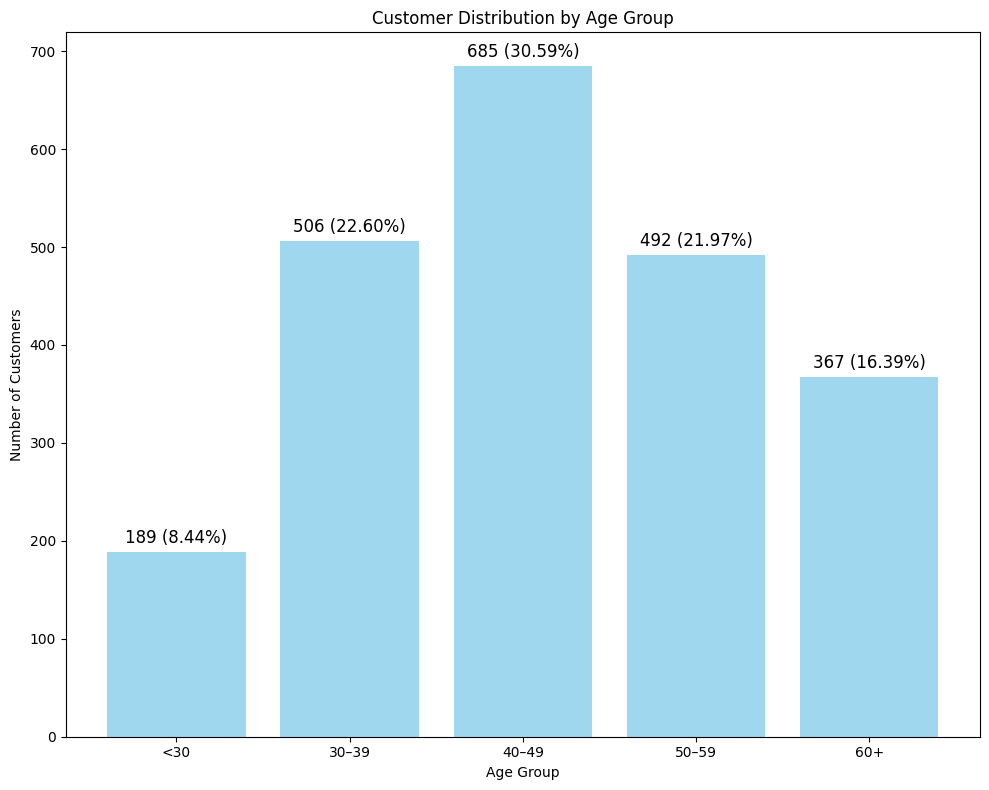

In [53]:
# Đếm số lượng của từng nhóm tuổi
age_counts = df_customer['Age_Group'].value_counts().sort_index()

# Biểu đồ thanh thể hiện các nhóm tuổi của khách hàng
plt.figure(figsize=(10,8))
bars = plt.bar(age_counts.index, age_counts.values, color='skyblue', alpha=0.8)

# Thêm giá trị và phần trăm vào từng thanh của biểu đồ
total = age_counts.sum()
for i, count in enumerate(age_counts):
    percentage = (count / total) * 100
    plt.text(i, count + 5, f'{count} ({percentage:.2f}%)', ha='center', va='bottom', fontsize=12)

# Thêm tiêu đề và nhãn cho biểu đồ
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Nhìn vào biểu đồ cột ở trên, ta có thể nhận thấy rằng:
- Chỉ có 2 khách hàng dưới 30 tuổi (0,09%),
- 187 khách hàng từ 30 đến 39 tuổi (8,36%),
- 506 khách hàng từ 40 đến 49 tuổi (22,62%),
- 685 khách hàng từ 50 đến 59 tuổi (30,62%),
- 857 khách hàng trên 60 tuổi (38,31%).

**Tôi cũng muốn biết tổng chi tiêu của khách hàng khi họ mua sắm tại cửa hàng này. Vì vậy, tôi sẽ tạo một biến mới có tên là Total_Spending.**

In [54]:
df_customer['Total_Spending'] = df_customer[['MntWines', 'MntFruits', 'MntMeatProducts',
                                              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

In [55]:
# Hiển thị tỉ lệ của từng giá trị trong trường "Total_Spending"
df_customer["Total_Spending"].value_counts(normalize=True).mul(100).round(2).sort_index()

Total_Spending
5       0.04
6       0.09
8       0.18
9       0.09
10      0.22
        ... 
2352    0.04
2440    0.04
2486    0.04
2524    0.04
2525    0.09
Name: proportion, Length: 1054, dtype: float64

**Ngoài ra còn có 2 biến khá tương đồng là Kidhome và Teenhome, tôi sẽ kết hợp chúng bằng cách tạo một biến mới có tên là Children**

In [56]:
# Tạo biến mới là Children bằng cách cộng Kidhome và Teenhome lại với nhau
df_customer['Children'] = df_customer['Kidhome'] + df_customer['Teenhome']

In [57]:
# Chi tiết về dataset sau khi tiền xử lý
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2239 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2239 non-null   int64         
 1   Year_Birth           2239 non-null   int64         
 2   Education            2239 non-null   object        
 3   Marital_Status       2239 non-null   object        
 4   Income               2239 non-null   float64       
 5   Kidhome              2239 non-null   int64         
 6   Teenhome             2239 non-null   int64         
 7   Dt_Customer          2239 non-null   datetime64[ns]
 8   Recency              2239 non-null   int64         
 9   MntWines             2239 non-null   int64         
 10  MntFruits            2239 non-null   int64         
 11  MntMeatProducts      2239 non-null   int64         
 12  MntFishProducts      2239 non-null   int64         
 13  MntSweetProducts     2239 non-null   i

In [58]:
df_customer.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Age,Age_Group,Total_Spending,Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,3,11,1,58,50–59,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,3,11,0,61,60+,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,3,11,0,50,50–59,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,3,11,0,31,30–39,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,3,11,0,34,30–39,422,1


Bước tiếp theo, tôi sẽ kiểm tra bất kỳ giá trị ngoại lai nào từ các biến số bằng cách sử dụng **biểu đồ hộp và biểu đồ histplot** để trực quan hóa.

Các biến số mà tôi sẽ kiểm tra như sau:
1. Income
2. Customer_Age
3. MntWines
4. MntFruits
5. MntMeatProducts
6. MntFishProducts
7. MntSweetProducts
8. MntGoldProds
9. NumWebPurchases
10. NumCatalogPurchases
11. NumStorePurchases
12. NumWebVisitsMonth
13. Recency
14. Total_Spending
15. Children

In [59]:
# Các biến số sẽ kiểm tra như sau:
numerical_variables = [
    'Income', 'Customer_Age',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency',
    'Total_Spending', 'Children'
]

# Các biến phân loại sẽ kiểm tra như sau:
categorical_variables = ['Education', 'Marital_Status', 'Age_Group']

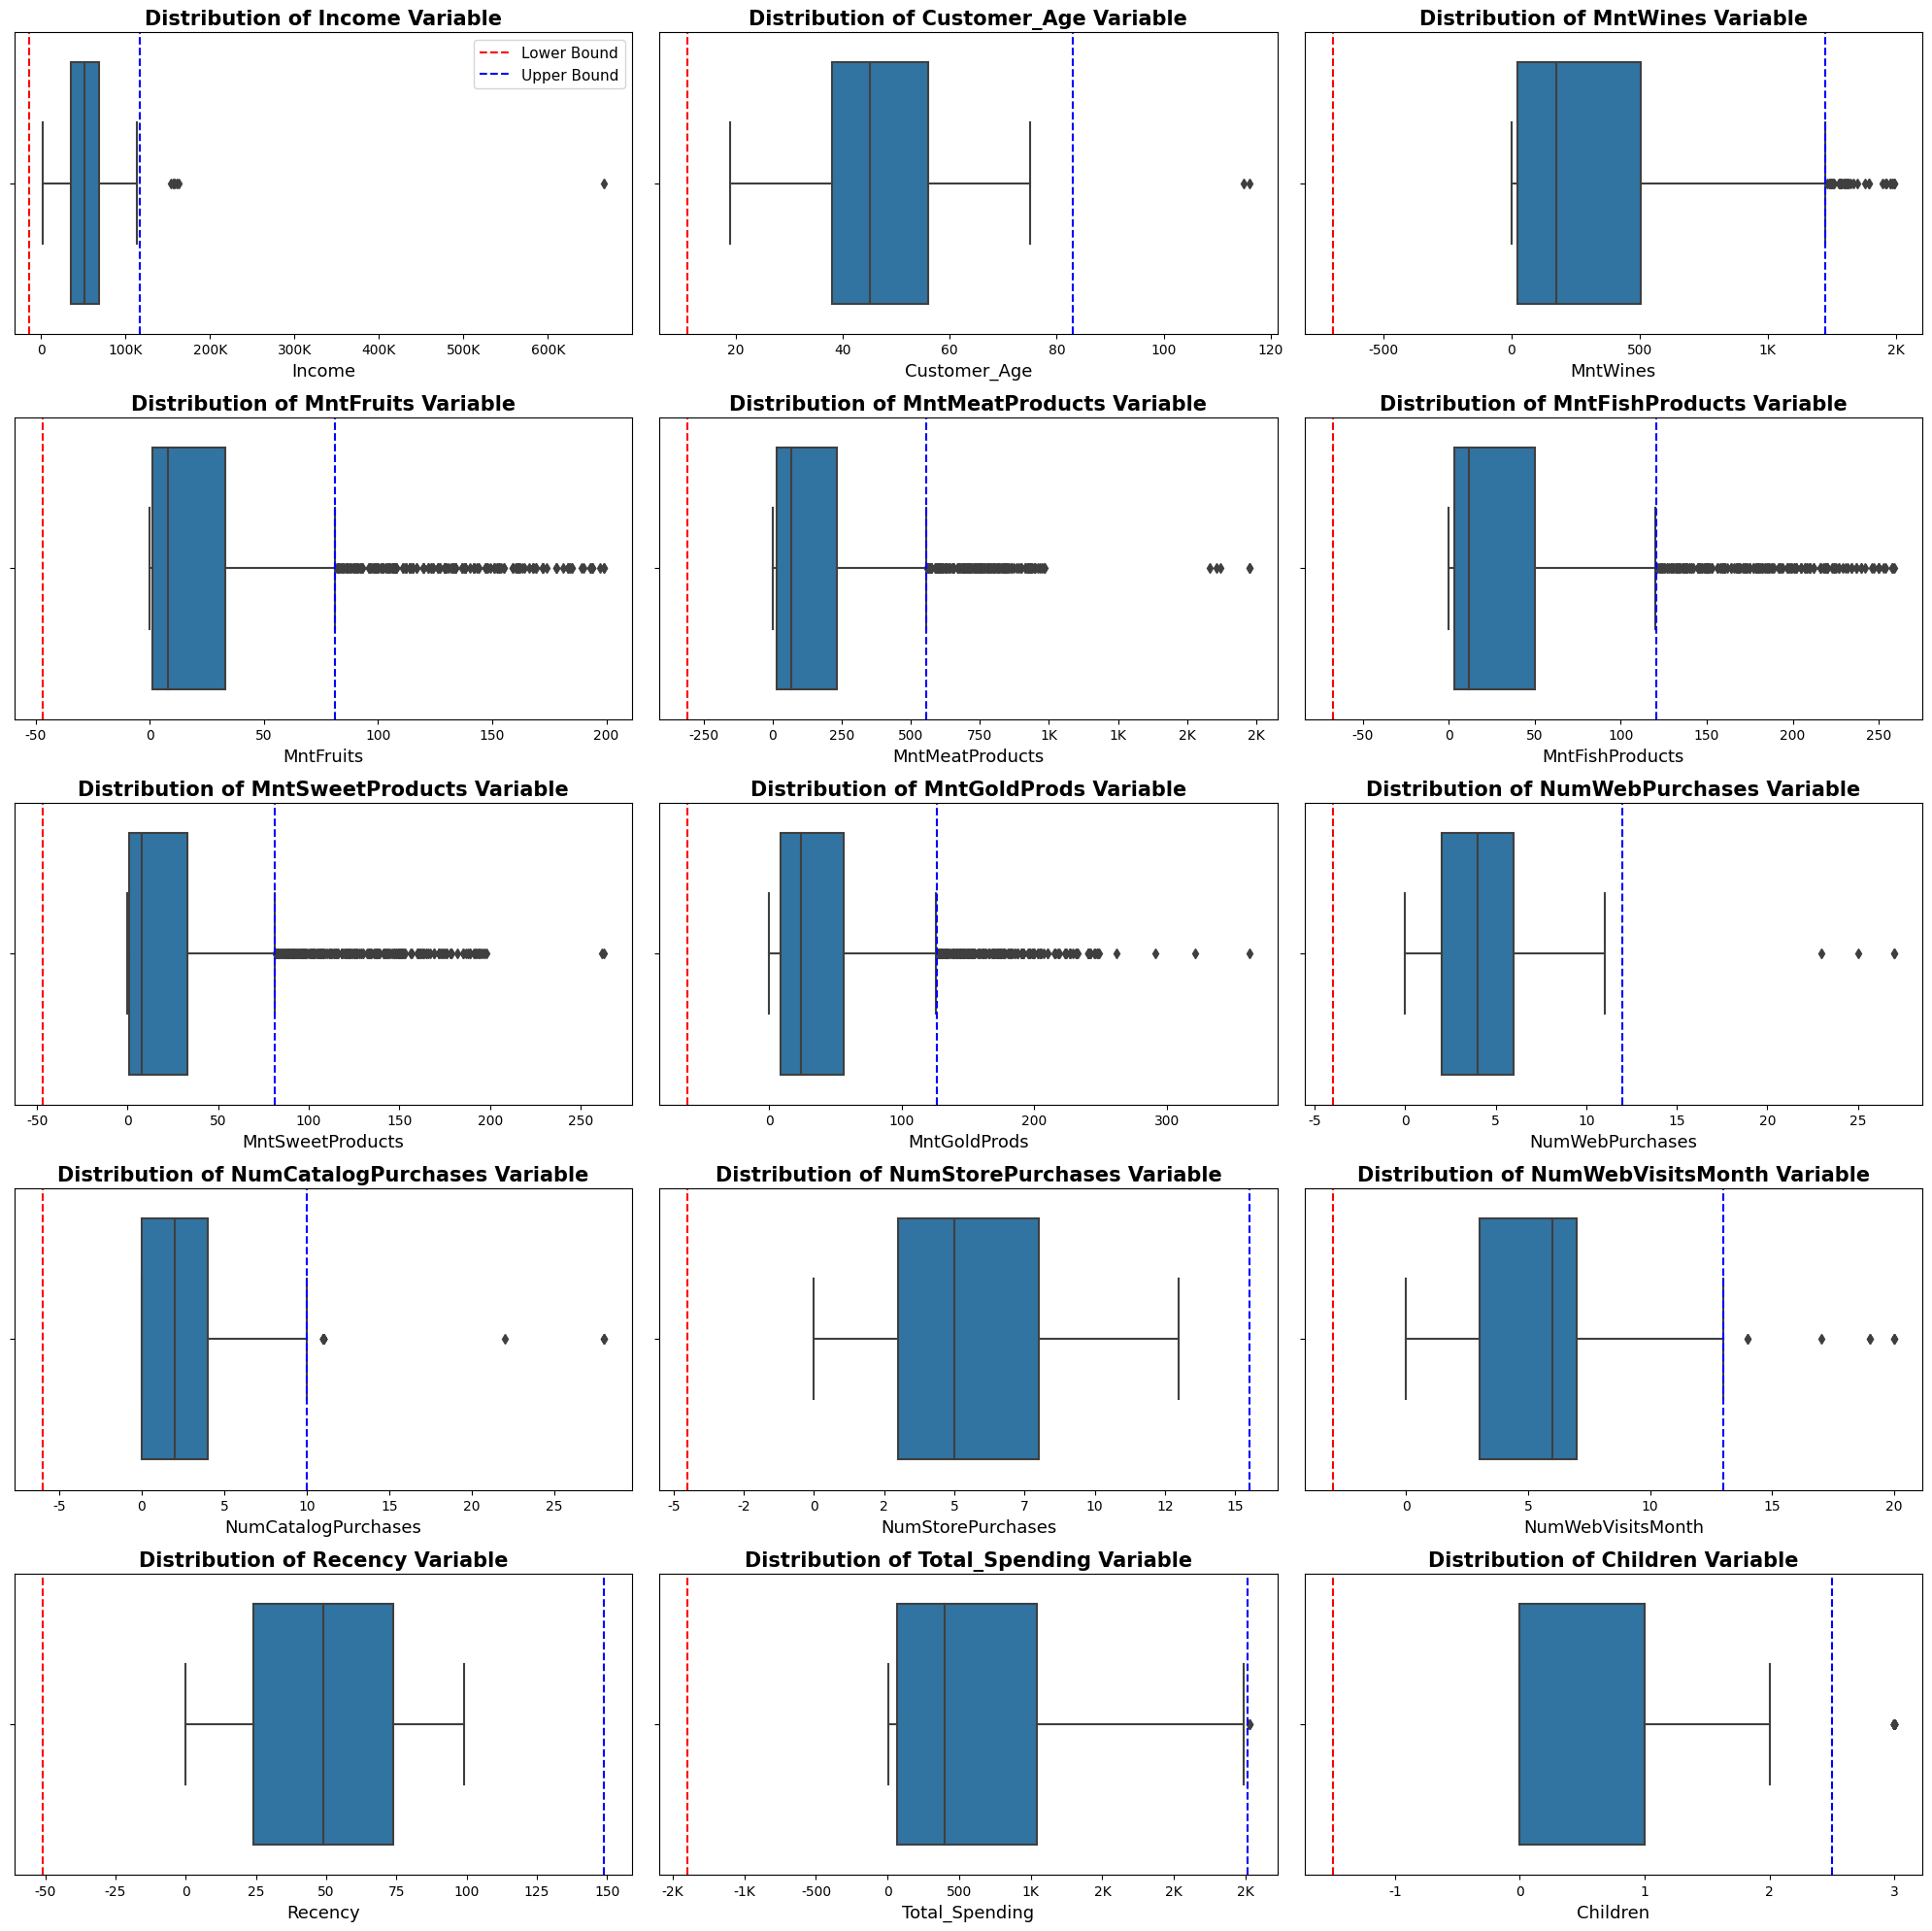

In [60]:
# Hàm định dạng số K và M (bao gồm cả giá trị âm)
# Ví dụ: chuyển 100,000 thành 100k và 1,000,000 thành 1M

def thousands_formatter(x, pos):
    abs_x = abs(x)
    if abs_x >= 1_000_000:
        formatted = f'{abs_x / 1_000_000:.0f}M'
    elif abs_x >= 1_000:
        formatted = f'{abs_x / 1_000:.0f}K'
    else:
        formatted = f'{int(abs_x)}'

    return f'-{formatted}' if x < 0 else formatted

formatter = FuncFormatter(thousands_formatter)

# Danh sách các biến số
numerical_variables = ['Income', 'Customer_Age',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency',
    'Total_Spending', 'Children']

# Tạo biểu đồ hộp cho từng biến số
rows, cols = 5, 3 # (5 hàng x 3 cột)
plt.figure(figsize=(20, 20))

# Lặp lại qua từng biến để vẽ biểu đồ hộp
for i, col in enumerate(numerical_variables):
    ax = plt.subplot(rows, cols, i + 1)
    sns.boxplot(data=df_customer, x=col, ax=ax)

    # Tính toán IQR để xác định ngưỡng ngoại lệ
    Q1 = df_customer[col].quantile(0.25)
    Q3 = df_customer[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Thêm các đường thẳng dọc để biểu thị ngưỡng ngoại lệ
    ax.axvline(lower_bound, color="red", linestyle="--", label="Lower Bound")
    ax.axvline(upper_bound, color="blue", linestyle="--", label="Upper Bound")   
    
    ax.set_title(f"Distribution of {col} Variable", fontsize=15, fontweight="bold")
    ax.set_xlabel(col, fontsize=13)
    ax.set_ylabel("")  
    ax.xaxis.set_major_formatter(formatter)  # Áp dụng định dạng K và M cho trục x

    # Thêm chú thích chỉ cho biểu đồ đầu tiên để tránh lặp lại
    if i == 0:
        ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

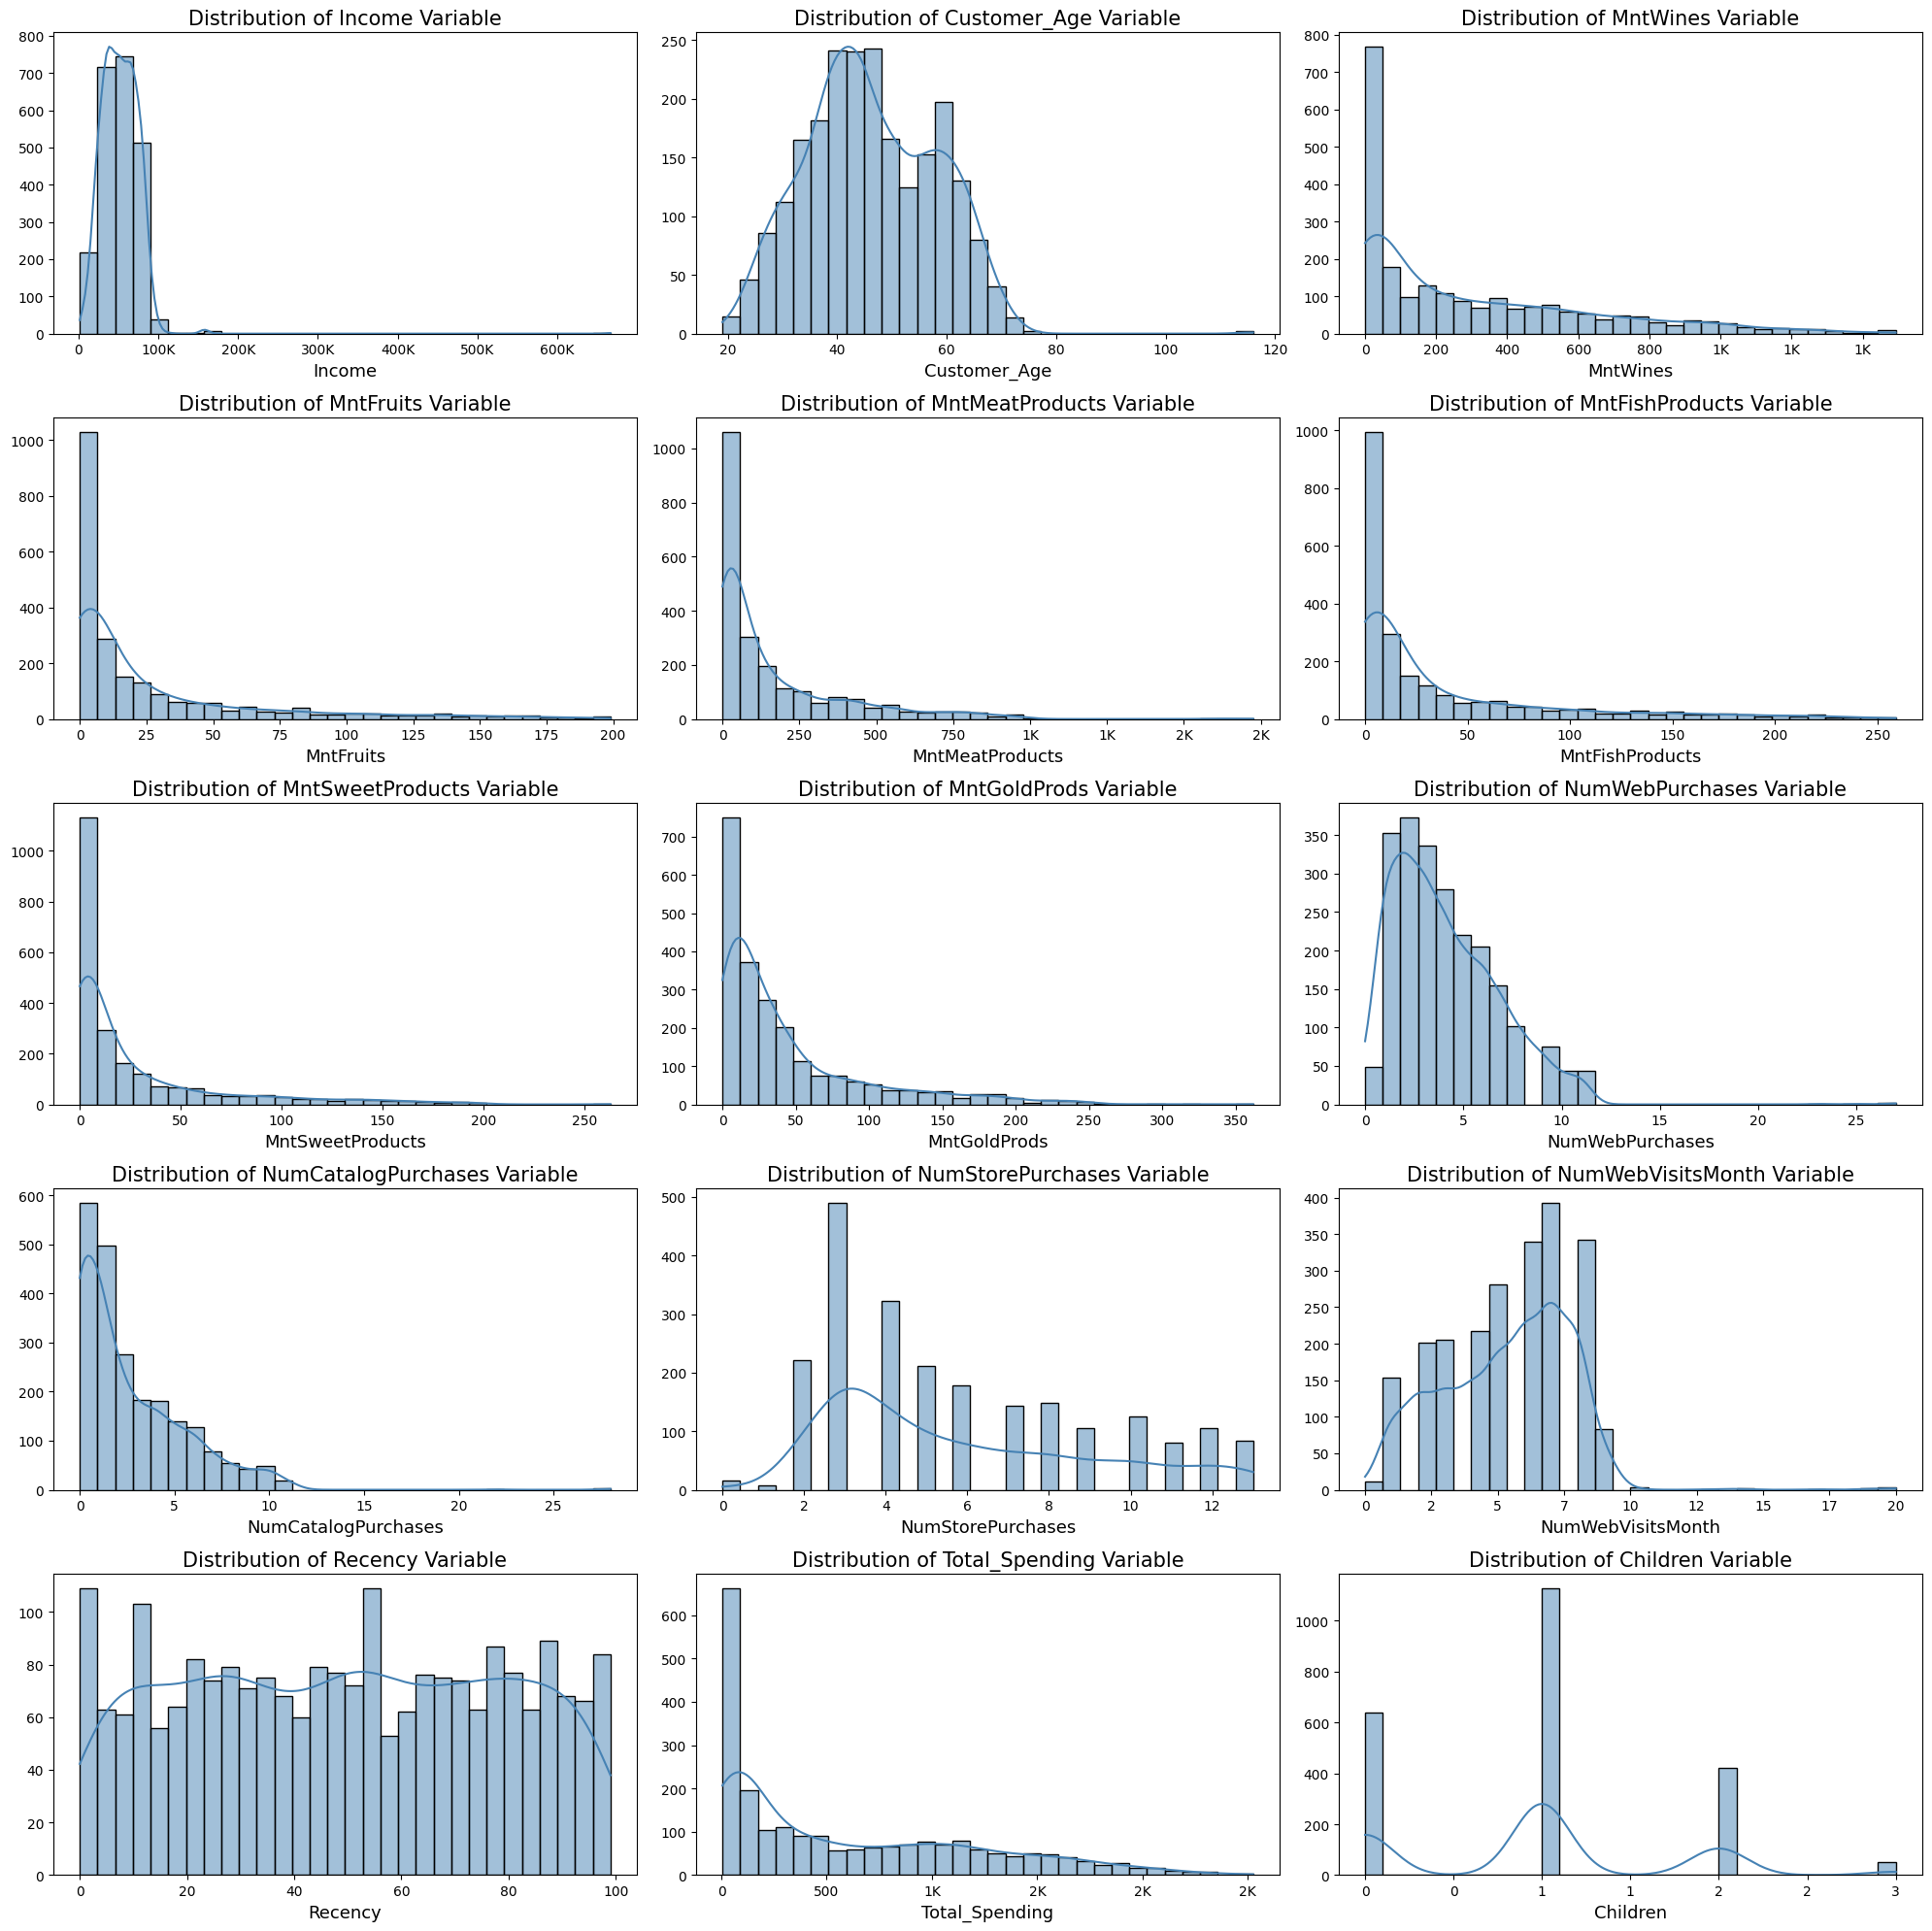

In [61]:
# Danh sách các biến số
numerical_variables = ['Income', 'Customer_Age',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency',
    'Total_Spending', 'Children']

# Tạo biểu đồ histogram cho từng biến số
rows, cols = 5, 3 # (5 hàng x 3 cột)
plt.figure(figsize=(20, 20))

# Lặp lại qua từng biến để vẽ biểu đồ histogram
for i, col in enumerate(numerical_variables):
    ax = plt.subplot(rows, cols, i + 1)
    sns.histplot(data=df_customer, x=col, kde=True, bins=30, ax=ax, color='steelblue', edgecolor='black')
    
    ax.set_title(f'Distribution of {col} Variable', fontsize=15)
    ax.set_xlabel(col, fontsize=13)
    ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=10)

    # Áp dụng định dạng số K và M (bao gồm cả giá trị âm)
    # Ví dụ: chuyển 100,000 thành 100k và 1,000,000 thành 1M
    ax.xaxis.set_major_formatter(formatter)

# Điều chỉnh bố cục để tránh chồng chéo
plt.tight_layout()
plt.show()

Tôi đã tạo biểu đồ hộp và biểu đồ histplot cho các biến/cột đã chọn để xác định bất kỳ giá trị ngoại lai nào.

Để giúp việc xác định giá trị ngoại lai dễ dàng hơn, tôi sẽ tính toán tỷ lệ phần trăm giá trị ngoại lai của các biến số liên quan đó bằng phương pháp IQR (khoảng liên phân vị).

In [62]:
# Đầu tiên, xác định các biến số cần kiểm tra
columns_to_check = [
    'Income', 'Customer_Age', 'MntWines', 'MntFruits',
    'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 
    'NumWebVisitsMonth', 'Recency', 'Total_Spending', 'Children'
]

# Hàm tính toán tỷ lệ phần trăm giá trị ngoại lai sử dụng phương pháp IQR
def calculate_outlier_percentage(df_customer, columns):
    outlier_data = []
    for col in columns:
        Q1 = df_customer[col].quantile(0.25)
        Q3 = df_customer[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df_customer[(df_customer[col] < lower_bound) | (df_customer[col] > upper_bound)]
        outlier_count = outliers.shape[0]
        outlier_percentage = (outlier_count / len(df_customer)) * 100
        outlier_data.append({
            'Variable': col,
            'Outlier Count': outlier_count,
            'Outlier Percentage (%)': round(outlier_percentage, 2)
        })
    return pd.DataFrame(outlier_data)

# Hiển thị tỷ lệ phần trăm giá trị ngoại lai cho các biến số đã chọn
outlier_stats = calculate_outlier_percentage(df_customer, columns_to_check)
print(outlier_stats)

               Variable  Outlier Count  Outlier Percentage (%)
0                Income              8                    0.36
1          Customer_Age              2                    0.09
2              MntWines             35                    1.56
3             MntFruits            227                   10.14
4       MntMeatProducts            175                    7.82
5       MntFishProducts            223                    9.96
6      MntSweetProducts            248                   11.08
7          MntGoldProds            207                    9.25
8       NumWebPurchases              4                    0.18
9   NumCatalogPurchases             23                    1.03
10    NumStorePurchases              0                    0.00
11    NumWebVisitsMonth              8                    0.36
12              Recency              0                    0.00
13       Total_Spending              3                    0.13
14             Children             53                 

Dựa trên phép tính giá trị ngoại lệ ở trên, tôi đã nghĩ đến việc **loại bỏ các giá trị/hàng** khỏi các biến/cột có **tỷ lệ ngoại lệ >5% bằng phương pháp IQR (khoảng liên phân vị)**.

Nhưng nếu tôi làm vậy, tôi sẽ loại bỏ 1.077 hàng khỏi 2.237 hàng còn lại, tức là khoảng 48%.

Do đó, tôi quyết định thử kỹ thuật **Winsorization (biến đổi giá trị ngoại lệ)** cho các biến có tỷ lệ ngoại lệ >5%.

Các biến sẽ được lọc bằng kỹ thuật Winsorization như sau:
1. **MntFruits**
2. **MntMeatProducts**
3. **MntFishProducts**
4. **MntSweetProducts**
5. **MntGoldProds**

**Winsorization** là một kỹ thuật xử lý giá trị ngoại lệ (giá trị cực trị) bằng cách thay thế các giá trị cực trị nhất bằng các giá trị ít cực trị hơn.

- **Ví dụ**: Nếu tập dữ liệu của tôi có các giá trị như [1, 2, 3, 100], Winsorization có thể thay đổi 100 thành 10 như một giới hạn được xác định trước.

- **Mục tiêu**: Giữ cho dữ liệu thực tế đồng thời giảm tác động của các giá trị cực trị.

In [63]:
# Biến số cần lọc giá trị ngoại lai
# Các biến có hơn 5% giá trị ngoại lai bên trong chúng
variables_to_filter = [
    'MntFruits',
    'MntMeatProducts',
    'MntSweetProducts',
    'MntFishProducts',
    'MntGoldProds'
]

# Hàm Winsorization để lọc giá trị ngoại lai (thay thế các giá trị cực đoan bằng các giá trị ít cực đoan hơn)
def winsorize_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

# Áp dụng hàm Winsorization cho các biến số đã chọn
for col in variables_to_filter:
    winsorize_outliers(df_customer, col)

In [64]:
# Kiểm tra lại xem còn giá trị ngoại lai không
for col in variables_to_filter:
    Q1 = df_customer[col].quantile(0.25)
    Q3 = df_customer[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    below_lower_bound = (df_customer[col] < lower_bound).sum()
    above_upper_bound = (df_customer[col] > upper_bound).sum()
    
    # Nếu không có giá trị ngoại lai, in ra thông báo
    print(f"{col}: Below lower bound = {below_lower_bound}, Above upper bound = {above_upper_bound}")

MntFruits: Below lower bound = 0, Above upper bound = 0
MntMeatProducts: Below lower bound = 0, Above upper bound = 0
MntSweetProducts: Below lower bound = 0, Above upper bound = 0
MntFishProducts: Below lower bound = 0, Above upper bound = 0
MntGoldProds: Below lower bound = 0, Above upper bound = 0


In [65]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2239 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2239 non-null   int64         
 1   Year_Birth           2239 non-null   int64         
 2   Education            2239 non-null   object        
 3   Marital_Status       2239 non-null   object        
 4   Income               2239 non-null   float64       
 5   Kidhome              2239 non-null   int64         
 6   Teenhome             2239 non-null   int64         
 7   Dt_Customer          2239 non-null   datetime64[ns]
 8   Recency              2239 non-null   int64         
 9   MntWines             2239 non-null   int64         
 10  MntFruits            2239 non-null   int64         
 11  MntMeatProducts      2239 non-null   int64         
 12  MntFishProducts      2239 non-null   float64       
 13  MntSweetProducts     2239 non-null   i

Sau khi áp dụng Winsorization cho các giá trị ngoại lai trong các biến đã chọn, tôi muốn loại bỏ một số biến/cột không sử dụng cho phân tích và phân cụm dữ liệu, bao gồm:
1. ID
2. Z_CostContact
3. Z_Revenue
4. Kidhome
5. Teenhome

In [66]:
print(df_customer.columns.tolist())

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Customer_Age', 'Age_Group', 'Total_Spending', 'Children']


In [67]:
# Loại bỏ các cột không sử dụng cho phân tích và phân cụm dữ liệu
columns_to_drop = ['ID', 'Z_CostContact', 'Z_Revenue', 'Kidhome', 'Teenhome']
df_customer.drop(columns=columns_to_drop, axis=1, inplace=True)

In [68]:
# Copy và lưu dataframe đã được làm sạch và xử lý vào một dataframe mới
df_customer_filtered = df_customer.copy()

In [69]:
df_customer_filtered.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Dt_Customer',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Customer_Age', 'Age_Group', 'Total_Spending',
       'Children'],
      dtype='object')

In [70]:
df_customer_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2239 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Year_Birth           2239 non-null   int64         
 1   Education            2239 non-null   object        
 2   Marital_Status       2239 non-null   object        
 3   Income               2239 non-null   float64       
 4   Dt_Customer          2239 non-null   datetime64[ns]
 5   Recency              2239 non-null   int64         
 6   MntWines             2239 non-null   int64         
 7   MntFruits            2239 non-null   int64         
 8   MntMeatProducts      2239 non-null   int64         
 9   MntFishProducts      2239 non-null   float64       
 10  MntSweetProducts     2239 non-null   int64         
 11  MntGoldProds         2239 non-null   float64       
 12  NumDealsPurchases    2239 non-null   int64         
 13  NumWebPurchases      2239 non-null   i

In [71]:
df_customer_filtered.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Age,Age_Group,Total_Spending,Children
0,1957,Graduation,Single,58138.0,2012-09-04,58,635,81,546,120.5,...,0,0,0,0,0,1,58,50–59,1617,0
1,1954,Graduation,Single,46344.0,2014-03-08,38,11,1,6,2.0,...,0,0,0,0,0,0,61,60+,27,2
2,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111.0,...,0,0,0,0,0,0,50,50–59,776,0
3,1984,Graduation,Together,26646.0,2014-02-10,26,11,4,20,10.0,...,0,0,0,0,0,0,31,30–39,53,1
4,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46.0,...,0,0,0,0,0,0,34,30–39,422,1


Trước khi tiến hành các bước tiếp theo, tôi sẽ chia phân tích cụm dữ liệu thành 2 phần, chẳng hạn như:

**A. Phân cụm dựa trên Age_Group và Sản phẩm.**

**B. Phân cụm dựa trên Age_Group và Kênh mua sắm.**

**LƯU DATASET ĐÃ XỬ LÝ**

Sau khi hoàn thành các bước xử lý dữ liệu trong phần III, chúng ta sẽ lưu dataset đã được làm sạch và chuẩn bị vào một file CSV mới để có thể sử dụng cho các phân tích tiếp theo.

In [72]:
# Lưu dataset đã xử lý thành file CSV mới
df_customer_filtered.to_csv('/kaggle/working/customer_data_processed.csv', index=False)

# Hiển thị thông báo xác nhận
print("Dataset đã được lưu thành công!")
print(f"Tên file: customer_data_processed.csv")
print(f"Số lượng dòng: {df_customer_filtered.shape[0]:,}")
print(f"Số lượng cột: {df_customer_filtered.shape[1]:,}")
print(f"Kích thước file: {df_customer_filtered.memory_usage(deep=True).sum() / 1024:.2f} KB")

Dataset đã được lưu thành công!
Tên file: customer_data_processed.csv
Số lượng dòng: 2,239
Số lượng cột: 28
Kích thước file: 738.71 KB


## IV. XỬ LÝ DỮ LIỆU

**A. Phân cụm dựa trên Age_Group và Products**

Hiện tại, tôi sẽ chọn một số biến cho phần đầu tiên của quy trình phân cụm. Tôi sẽ phân cụm giữa Age_Groups và loại sản phẩm đã mua. Các biến được chọn như sau:
1. Age_Group
2. MntWines
3. MntFruits
4. MntMeatProducts
5. MntFishProducts
6. MntSweetProducts
7. MntGoldProds

**Mục tiêu của tôi khi phân cụm này là khám phá và xác định cách các nhóm tuổi khác nhau chi tiêu cho các loại sản phẩm khác nhau. Điều này giúp xác định các mô hình mua sắm và sở thích liên quan đến độ tuổi.**

Tôi sẽ sử dụng phương pháp KMeans để phân cụm và áp dụng PCA, biểu đồ phân tán và bản đồ nhiệt để trực quan hóa.

**Trong phần này, tôi cũng sẽ mã hóa các Biến Phân loại có liên quan và chuẩn hóa các Biến Số có liên quan theo mục tiêu của phân cụm, một phần của Xử lý Dữ liệu.**

Sau đó, tôi sẽ tiến hành Chuẩn bị Mô hình cho mô hình học máy không giám sát, tức là phân cụm.

In [73]:
# Các biến số sẽ sử dụng cho phân cụm dữ liệu
cluster_a_df = df_customer_filtered[['Age_Group', 'MntWines', 'MntFruits', 'MntMeatProducts',
                                     'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']]

In [74]:
# Xem các giá trị duy nhất và tính tổng số giá trị của từng Products

summary = pd.DataFrame()

for col in ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']:
    counts = df_customer_filtered[col].value_counts().sort_index()
    summary = pd.concat([summary, counts], axis=1)

summary.columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
print(summary)

       MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0.0        13.0      399.0              1.0            384.0   
1.0        37.0      162.0             14.0             10.0   
2.0        42.0      120.0             30.0            156.0   
3.0        30.0      116.0             40.0            130.0   
4.0        33.0      104.0             30.0            108.0   
...         ...        ...              ...              ...   
540.0       NaN        NaN              1.0              NaN   
549.0       NaN        NaN              2.0              NaN   
550.0       NaN        NaN              1.0              NaN   
120.5       NaN        NaN              NaN            223.0   
126.5       NaN        NaN              NaN              NaN   

       MntSweetProducts  MntGoldProds  
0.0               418.0          61.0  
1.0               161.0          73.0  
2.0               128.0          61.0  
3.0               101.0          69.0  
4.0                82.0        

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [75]:
# Vì Age_group là một biến phân loại, tôi phải chuyển chúng thành số
# Python chỉ có thể 'đọc' các biến số, không phải biến phân loại
# Do đó, tôi sẽ biến đổi Age_Group thành các số bằng cách mã hóa các giá trị của nó

# Mã hóa Age_Group trong dataset df_customer_filtered
le = LabelEncoder()
df_customer_filtered['Age_Group_Encoded'] = le.fit_transform(df_customer_filtered['Age_Group'])

# Vì tôi đã có phiên bản mã hóa của Age_Group là Age_Group_Encoded, nên tôi sẽ sửa đổi các biến đã chọn cho phân cụm
cluster_a_df = df_customer_filtered[['Age_Group_Encoded', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']]

In [76]:
# Tiếp theo tôi sẽ chuẩn hóa cluster_a_df
scaler = StandardScaler()
cluster_a_scaled = scaler.fit_transform(cluster_a_df)